# Model Comparison & Statistical Analysis

**Objective:** Compare the trained classifiers using rigorous statistical tests and ROC analysis to determine whether observed performance differences are statistically significant.

---

### Table of Contents

1. [Setup & Data Loading](#1)
2. [Corrected Resampled Paired t-test](#2)
3. [ROC Curves & ROC Convex Hull (ROCCH)](#3)
4. [Final Conclusions & Model Selection](#4)
5. [Next Steps](#5)


<a id='1'></a>
## 1. Setup & Data Loading

Import required libraries, configure the global plotting style, and load the evaluation results saved during the training phase.


In [1]:
import joblib
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import roc_curve, auc
from scipy.spatial import ConvexHull

from config import RESULTS_DIR

# Global settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

# Plotting style
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
FIG_DPI = 120
plt.rcParams.update({
    "figure.dpi": FIG_DPI,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.titlesize": 16,
    "figure.titleweight": "bold",
})

# Load evaluation results from the training phase
main_results = joblib.load(f"{RESULTS_DIR}/cv_evaluation_results.pkl")
baseline_results = joblib.load(f"{RESULTS_DIR}/1r_baseline_results.pkl")

# Combine results from both evaluations
all_results = {**baseline_results, **main_results}
models = list(all_results.keys())
print(f"Models loaded: {models}")


Models loaded: ['1R_Baseline', 'Logistic_Regression', 'KNN', 'Random_Forest']


<a id='2'></a>
## 2. Corrected Resampled Paired t-test

Using the standard Student's t-test on measurements derived from Cross-Validation on a single dataset suffers from **dependent estimates**: because training sets overlap, the true variance is underestimated and the test becomes overly liberal.

To address this issue, we apply the **Corrected Resampled t-test** (Nadeau & Bengio, 2003).
The corrected $t$ statistic is:

$$t = \frac{m_d}{\sqrt{(\frac{1}{k} + \frac{n_2}{n_1})\sigma_d^2}}$$

Where:
* **$k = 100$**: The total number of estimates, derived from our **10-Times Repeated 10-Fold Cross-Validation**. This provides 99 degrees of freedom, significantly increasing the statistical power of the test compared to a single CV run.
* **$n_2 / n_1 = 1/9$**: The ratio between the test set size (10%) and the training set size (90%) in each individual fold split.
* **$m_d$** and **$\sigma_d^2$**: The mean and the sample variance of the differences between the two models' scores across all 100 evaluations.


In [8]:
def corrected_resampled_ttest(scores_A, scores_B, k=100, n1_ratio=0.9, n2_ratio=0.1):
    differences = np.array(scores_A) - np.array(scores_B)
    m_d = np.mean(differences)
    sigma2_d = np.var(differences, ddof=1)

    # Train/test ratio (n2/n1)
    ratio = n2_ratio / n1_ratio
    denominator = np.sqrt((1 / k + ratio) * sigma2_d)

    # Avoid division by zero in case of zero variance
    if denominator == 0:
        return 0.0, 1.0

    t_stat = m_d / denominator

    # Two-tailed p-value (Student's t, df = k-1 -> 99 degrees of freedom for 100 repeats)
    p_value = stats.t.sf(np.abs(t_stat), df=k - 1) * 2
    return t_stat, p_value


# Pairwise comparisons
ALPHA = [0.05, 0.01]  # Significance levels for annotations
p_values_matrix = pd.DataFrame(index=models, columns=models, dtype=float)
results_table = []

for i in range(len(models)):
    for j in range(i + 1, len(models)):
        model_A, model_B = models[i], models[j]
        scores_A = all_results[model_A]["f1_scores"]
        scores_B = all_results[model_B]["f1_scores"]

        t_stat, p_val = corrected_resampled_ttest(scores_A, scores_B, k=100)

        p_values_matrix.loc[model_A, model_B] = p_val
        p_values_matrix.loc[model_B, model_A] = p_val

        if p_val < ALPHA[1]:
            sig = "** (p < 0.01)"
        elif p_val < ALPHA[0]:
            sig = "*  (p < 0.05)"
        else:
            sig = "ns (p >= 0.05)"

        results_table.append({
            "Model A": model_A,
            "Model B": model_B,
            "Mean F1 A": round(np.mean(scores_A), 4),
            "Mean F1 B": round(np.mean(scores_B), 4),
            "t-statistic": round(t_stat, 3),
            "p-value": round(p_val, 4),
            "Significance": sig,
        })

# Fill diagonal
for model in models:
    p_values_matrix.loc[model, model] = 1.0

# ── Styled summary table
def _sig_style(v):
    if "**" in str(v):
        return "color: #d62728; font-weight: bold"
    if "*" in str(v):
        return "color: #ff7f0e; font-weight: bold"
    return "color: #2ca02c"

summary_df = pd.DataFrame(results_table)
print("Corrected Resampled Paired t-test (F1 Score)")
display(
    summary_df.style
    .format({
        "Mean F1 A": "{:.4f}",
        "Mean F1 B": "{:.4f}",
        "t-statistic": "{:.3f}",
        "p-value": "{:.4f}",
    })
    .map(_sig_style, subset=["Significance"])
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#3A86FF"), ("color", "white"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])
    .hide(axis="index")
)


Corrected Resampled Paired t-test (F1 Score)


Model A,Model B,Mean F1 A,Mean F1 B,t-statistic,p-value,Significance
1R_Baseline,Logistic_Regression,0.8338,0.8722,-3.469,0.0008,** (p < 0.01)
1R_Baseline,KNN,0.8338,0.8764,-3.587,0.0005,** (p < 0.01)
1R_Baseline,Random_Forest,0.8338,0.8775,-4.064,0.0001,** (p < 0.01)
Logistic_Regression,KNN,0.8722,0.8764,-0.477,0.6347,ns (p >= 0.05)
Logistic_Regression,Random_Forest,0.8722,0.8775,-0.705,0.4827,ns (p >= 0.05)
KNN,Random_Forest,0.8764,0.8775,-0.142,0.8872,ns (p >= 0.05)


### Interpretation

The table above reports the corrected t-statistic and p-value for all pairwise model comparisons based on 10-fold CV F1 scores. Significance levels:

| Symbol | Meaning |
|--------|---------|
| **\*\*** | Significant at $\alpha = 0.01$: strong evidence of a performance difference |
| **\*** | Significant at $\alpha = 0.05$: moderate evidence of a performance difference |
| **ns** | Not significant: insufficient evidence to conclude a meaningful difference |


The Corrected Resampled Paired t-test, utilizing the enhanced statistical power of our 10x10 Repeated Nested CV ($k=100$, $df=99$), reveals the following key insights:

1. **Validation of Multivariate Machine Learning:** All three complex models (Logistic Regression, KNN, and Random Forest) significantly outperform the `1R_Baseline` with high statistical confidence ($p < 0.01$). This formally justifies the implementation and computational cost of complex ML algorithms over simple, single-feature heuristic rules for this dataset.

2. **A Three-Way Statistical Tie:** The most important finding is the complete lack of statistically significant differences among the three main classifiers. When comparing Logistic Regression, KNN, and Random Forest against each other, the p-values are extremely high. This indicates that the small observed differences in their Mean F1-Scores fall strictly within the natural margin of error of the evaluation process. The models simply trade minor advantages fold by fold, meaning no single algorithm proves consistently superior to the others on this dataset.

<a id='3'></a>
## 3. ROC Curves & ROC Convex Hull (ROCCH)

Although `1R_Baseline` is a hard/discrete classifier and does not produce continuous probability scores, it can still be represented in ROC space as a **single operating point** (connected to the trivial coordinates $(0,0)$ and $(1,1)$).

Computing the **ROC Convex Hull** identifies the set of non-dominated classifiers: any model whose ROC curve never touches the convex hull (golden line) is sub-optimal regardless of the cost ratio $(C_{FP}$ vs $C_{FN})$.


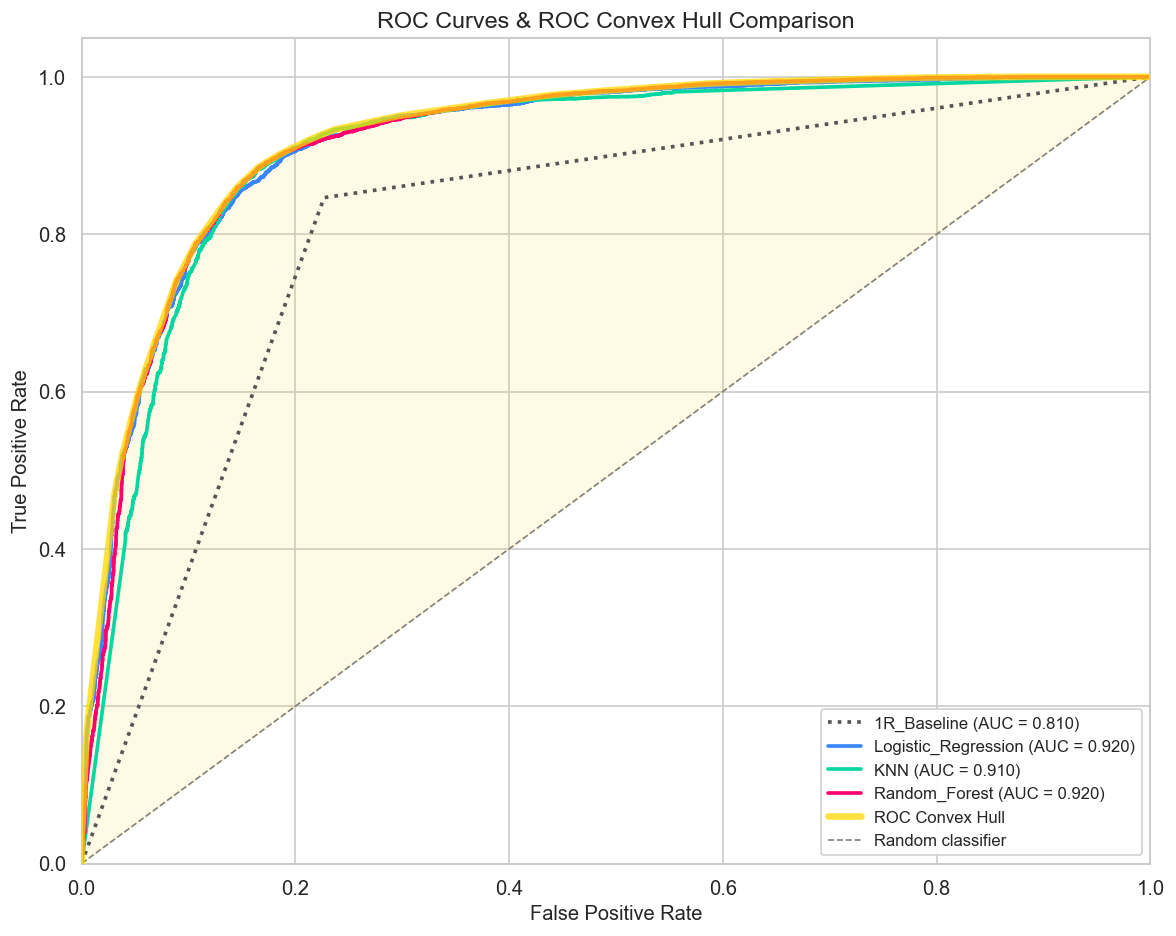

In [5]:
COLORS = {
    "1R_Baseline":         "#555555",
    "Logistic_Regression":  "#3A86FF",
    "KNN":                  "#06D6A0",
    "Random_Forest":        "#FF006E",
}
LINESTYLES = {
    "1R_Baseline":         ":",
    "Logistic_Regression":  "-",
    "KNN":                  "-",
    "Random_Forest":        "-",
}

fig, ax = plt.subplots(figsize=(10, 8))

# Accumulate all (FPR, TPR) points for the convex hull
all_fpr = [0.0, 1.0]
all_tpr = [0.0, 1.0]

for model_name in models:
    y_true = np.array(all_results[model_name]["y_true"])
    y_prob = np.array(all_results[model_name]["y_prob"])

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    all_fpr.extend(fpr)
    all_tpr.extend(tpr)

    ax.plot(
        fpr, tpr,
        color=COLORS.get(model_name, "orange"),
        linestyle=LINESTYLES.get(model_name, "-"),
        lw=2.2,
        label=f"{model_name} (AUC = {roc_auc:.3f})",
    )

# ROC Convex Hull 
points = np.column_stack((all_fpr, all_tpr))
hull = ConvexHull(points)
hull_pts = points[hull.vertices]

# Sort by FPR, then keep only the upper (non-decreasing TPR) frontier
# Use lexsort to sort by FPR first, then TPR, ensuring we can easily filter the upper hull
hull_pts = hull_pts[np.lexsort((hull_pts[:, 1], hull_pts[:, 0]))]
upper_hull = [hull_pts[0]]
for pt in hull_pts[1:]:
    if pt[1] >= upper_hull[-1][1]:
        upper_hull.append(pt)
upper_hull = np.array(upper_hull)

ax.plot(
    upper_hull[:, 0], upper_hull[:, 1],
    color="gold", lw=4, alpha=0.75, zorder=5,
    label="ROC Convex Hull",
)
ax.fill_between(
    upper_hull[:, 0], upper_hull[:, 1], upper_hull[:, 0],
    color="gold", alpha=0.10,
)
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random classifier")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves & ROC Convex Hull Comparison")
ax.legend(loc="lower right", fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/roc_convex_hull_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation of ROC Analysis

The ROC curves and the resulting ROC Convex Hull (ROCCH) provide a geometric perspective on model performance across all possible classification thresholds, perfectly complementing our statistical findings:

1. **The Dominance of Logistic Regression and Random Forest:** Visually, the curves for Logistic Regression and Random Forest are nearly identical, completely overlapping in the upper-left region of the graph. This is confirmed by their identical Area Under the Curve (AUC = 0.921). This geometric tie perfectly mirrors the statistical tie observed in the resampled t-test.

2. **The ROC Convex Hull:** The golden line (ROCCH) represents the optimal upper boundary of our predictive system. It is constructed almost entirely by the segments of the Logistic Regression and Random Forest curves. Any point on this golden boundary represents an optimal operational threshold, depending on the specific clinical cost associated with False Positives versus False Negatives.

3. **The Sub-optimality of KNN:** Although the t-test showed that KNN's F1-Score was not strictly significantly worse at $\alpha = 0.05$, the ROC space reveals its true behavior. The KNN curve (AUC = 0.910) lies almost entirely *below* the Convex Hull. This means that for almost any given asymmetry in misclassification costs, there exists a combination of Logistic Regression or Random Forest that will yield a better True Positive / False Positive trade-off than KNN. KNN is, therefore, a **geometrically dominated strategy**.

4. **Baseline Validation:** As expected, the discrete `1R_Baseline` forms a lower curve (AUC = 0.810) positioned deep inside the hull, graphically validating the immense added value of the multivariate classifiers. The 1R_Baseline is plotted as a dotted line featuring a single sharp "elbow", rather than a smooth, multi-step curve like the other models. This is because 1R is a *hard (discrete) classifier*: it outputs absolute class predictions (0 or 1) rather than a continuous range of probabilities. Consequently, it only evaluates to a single, fixed operating point in the ROC space. To plot its curve and calculate the AUC (0.810), this single point is mathematically connected to the trivial extremes of the space: $(0,0)$ (predicting all instances as negative) and $(1,1)$ (predicting all instances as positive). This visually underscores its rigidity compared to the probabilistic flexibility of the multivariate models.

<a id='4'></a>
## 4. Final Conclusions & Model Selection

This notebook presented a rigorous comparative analysis of three multivariate Machine Learning algorithms against a heuristic baseline (1R) for Heart Disease prediction. By combining strict statistical validation with geometric performance evaluation, we reached the following conclusions:

1. **The Value of Machine Learning:** The Corrected Resampled t-test and the ROC analysis definitively prove that all multivariate models (Logistic Regression, KNN, and Random Forest) significantly outperform the 1R baseline. This justifies the deployment of complex ML pipelines over simple rule-based approaches.
2. **The Performance Tie:** Both the statistical analysis ($p$-values $> 0.05$ between top models) and the ROC Convex Hull (overlapping AUC $= 0.921$) indicate a structural tie between Logistic Regression and Random Forest. Neither model consistently dominates the other across the repeated cross-validation folds.
3. **The Final Choice:** In a clinical context, when two models exhibit statistically indistinguishable predictive performance, the preference must always lean towards the intrinsically interpretable model (White-Box). While Random Forest operates as a Black-Box requiring post-hoc explainers, **Logistic Regression provides exact, transparent mathematical equations** (Odds Ratios) that healthcare professionals can directly interpret and validate.

<a id='5'></a>
## 5. Next Steps
Having crowned **Logistic Regression** as the optimal operational model for this dataset, the next phase of this project will focus on its clinical application. In the subsequent notebook (`final_model_interpretation.ipynb`), we will train the optimal Logistic Regression architecture on the entire 100% of the dataset to extract its final internal weights and translate them into actionable medical insights (Odds Ratios).